<a href="https://colab.research.google.com/github/Jquishpeq923/Machine-Learning-6-SIN-A-Mar-Jul-2026/blob/Metrics/Bias_vs_Variance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bias and Variance Analysis

* **Subject:** Machine Learning
* **Student:** José Alexander Quishpe Reinoso
* **Date:** May 24, 2026

---

## The Fundamental Dilemma: Bias vs. Variance

When we train a Machine Learning model, our true goal isn't for it to memorize the data we already have, but to acquire the ability to **generalize**; that is, to make accurate decisions when faced with information it has never seen before.

In this pursuit, we constantly face two major sources of error: bias and variance. Building a good predictive model isn't about achieving zero error (which is mathematically impossible in real-world scenarios), but about mastering the art of balancing these two forces—a concept known as the bias-variance trade-off.

* **1. Bias: The Algorithm's "Stubbornness"**
Bias represents the average difference between our model's predictions and the actual values. You can think of bias as a model that has preconceived notions and refuses to change its mind in the face of evidence. A model with **high bias** suffers from being too simple (*underfitting*). It's like trying to explain a complex curve using only a straight line: the algorithm imposes a rigid mathematical structure, completely ignoring the nuances of the real data.

* **2. Variance: "Hypersensitivity" to Noise**
On the other hand, variance measures how much our model's predictions would change if we trained it on a slightly different dataset. A model with **high variance** suffers from the opposite problem (*overfitting*). It is the algorithmic equivalent of a student who memorizes even the typos in a textbook instead of understanding the underlying theory. The model develops such a complex architecture that it fits the random fluctuations and "noise" of the training data perfectly. The result? An illusory precision that completely collapses when faced with the real world.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings('ignore')

# 1. Data preparation (Our mathematical "truth" + real-world noise)
np.random.seed(42)
num_samples = 60
X_data = np.sort(np.random.uniform(-np.pi, np.pi, num_samples))

# We generate a pure sine wave and inject Gaussian noise
y_noisy = np.sin(X_data) + np.random.normal(0, 0.35, num_samples)

# Continuous X vector so the plots are drawn as smooth lines
X_continuous = np.linspace(-np.pi, np.pi, 300).reshape(-1, 1)

def analyze_polynomial(degree):
    """
    Trains a polynomial regression model and plots the prediction curve
    to visually and mathematically compare it with the true function.
    """
    # Polynomial projection: we expand our dimensions to provide flexibility
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X_data.reshape(-1, 1))

    # Model fitting using Ordinary Least Squares (OLS)
    model = LinearRegression()
    model.fit(X_poly, y_noisy)

    # Calculate predictions and error
    y_pred_train = model.predict(X_poly)
    y_pred_curve = model.predict(poly.transform(X_continuous))
    mse = mean_squared_error(y_noisy, y_pred_train)

    # Graphical interface configuration
    plt.figure(figsize=(8, 4.5))
    plt.scatter(X_data, y_noisy, color='#888888', alpha=0.6, s=40, label='Training Data (Noisy)')
    plt.plot(X_continuous, np.sin(X_continuous), color='#2ca02c', linestyle='--', linewidth=2.5, label='True Function $y = \sin(x)$')
    plt.plot(X_continuous, y_pred_curve, color='#d62728', linewidth=2.5, label=f'Model Prediction (Degree {degree})')

    # Plot metadata
    plt.title(f'Polynomial Evaluation: Degree {degree} | MSE Error: {mse:.4f}', fontsize=13)
    plt.xlabel('Independent Variable (X)', fontsize=11)
    plt.ylabel('Dependent Variable (Y)', fontsize=11)
    plt.ylim(-2.0, 2.0)
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

### Scenario 1: The Underfitting Problem
**Clinical Diagnosis: High Bias, Low Variance**

What happens when we force a degree-1 polynomial? Mathematically, we are forcing the algorithm to use a straight line ($y = w_1x + w_0$). However, the nature of our data comes from a non-linear curve (the sine function).

Here we see **high bias** in action: the model is inflexible and assumes linearity even though the data screams otherwise. It has **low variance** because it is highly stable; if we extract 60 completely different points, the line it draws will be practically the same. It is a model that doesn't fluctuate, but is consistently wrong.

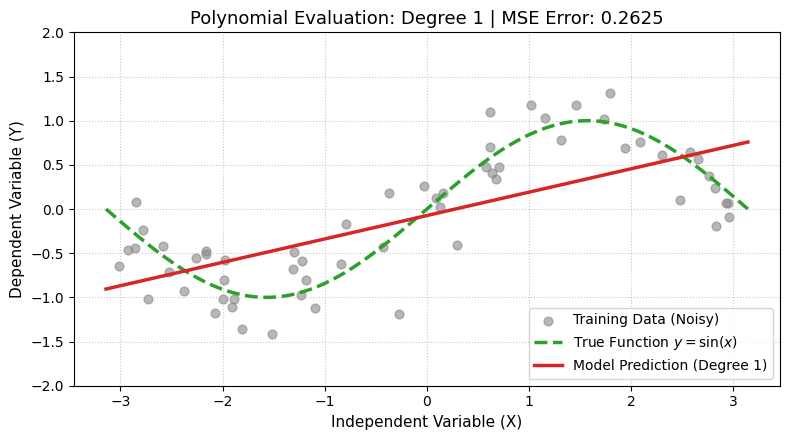

In [6]:
analyze_polynomial(degree=1)

### Scenario 2: The Ideal Balance (Good Generalization)
**Clinical Diagnosis: Low Bias, Low Variance**

By upgrading the model to degree 4, we give it exactly the mathematical degrees of freedom it needs to curve and follow the underlying pattern.

We drastically reduce the bias because the model now has the capacity to adapt to the true mathematical shape, but we prevent it from crossing the line into hypersensitivity. It is robust enough to ignore the "static" or random noise of the individual points. The model hasn't memorized the training data; it has **understood the real relationship**, which guarantees it will perform excellently on new data.

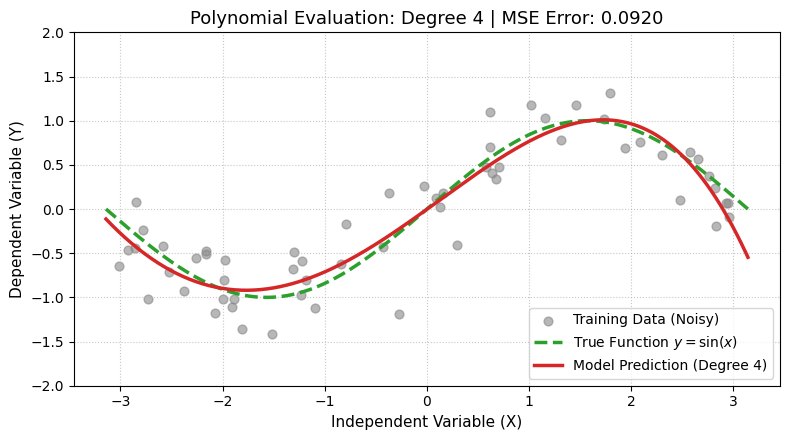

In [7]:
analyze_polynomial(degree=4)

### Scenario 3: The Overfitting Trap
**Clinical Diagnosis: Low Bias, High Variance**

If we skyrocket the complexity to a degree-20 polynomial, we are giving the algorithm a massive amount of adjustable parameters. At a calculus level, the model uses this excessive freedom to contort violently and pass almost directly through the center of every single training point. This is why it reports the lowest Mean Squared Error (MSE) during the training phase.

But beware, **this is an optical and mathematical illusion**. The model has falsely assumed that the random noise (the natural dispersion of the sample) is useful information. It suffers from **high variance** because this highly erratic curve is a slave to *this* specific sample of 60 points. If we try to predict new values, the curve will fluctuate so wildly that the predictions will be completely useless.

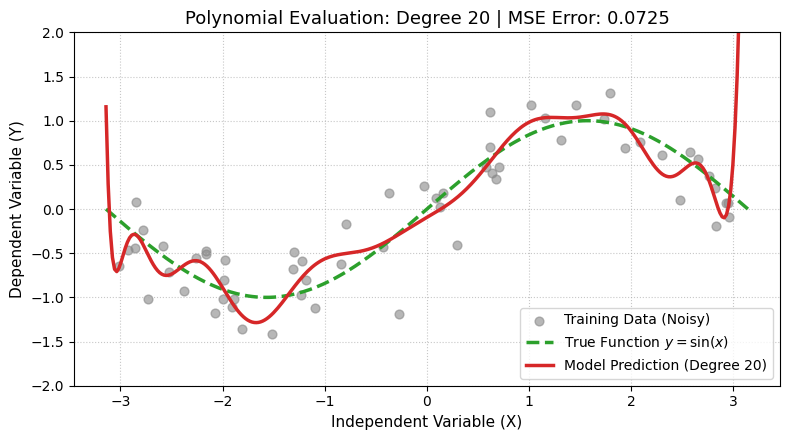

In [8]:
analyze_polynomial(degree=20)